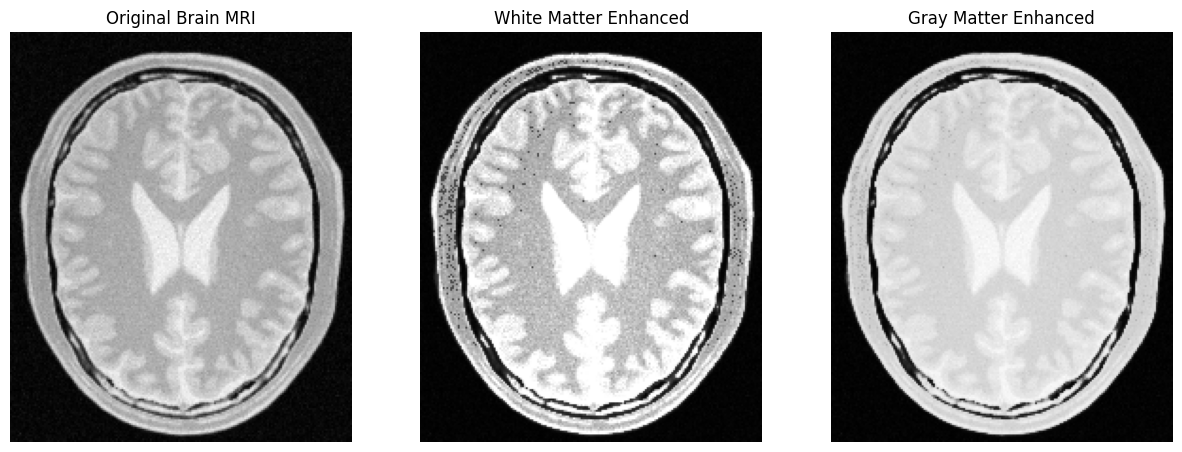

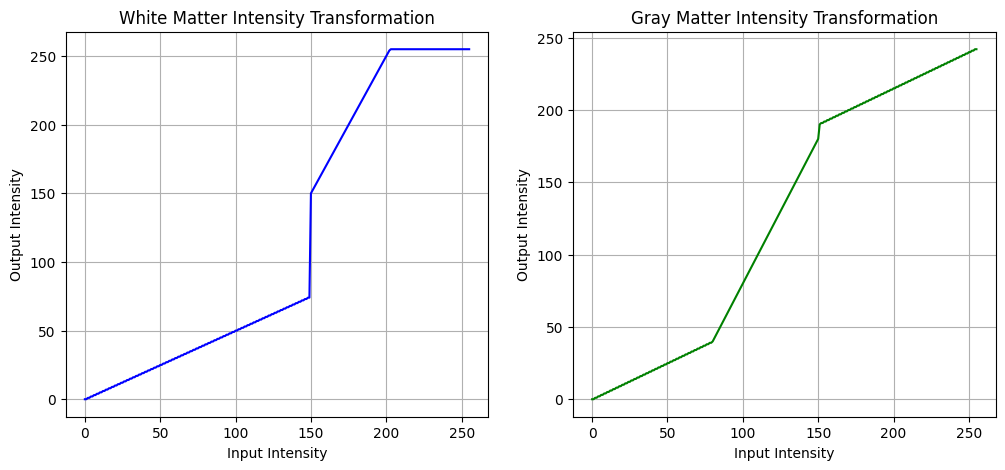

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

img = cv2.imread("/content/sample_data/brain_proton_density_slice.png", cv2.IMREAD_GRAYSCALE)

def white_matter_transform(pixel):
    if pixel < 150:
        return int(0.5 * pixel)
    else:
        return int(min(255, 2 * (pixel - 150) + 150))

def gray_matter_transform(pixel):
    if pixel < 80:
        return int(0.5 * pixel)
    elif pixel <= 150:
        return int(min(255, 2 * (pixel - 80) + 40))
    else:
        return int(0.5 * (pixel - 150) + 190)


white_transform_vec = np.vectorize(white_matter_transform)
gray_transform_vec = np.vectorize(gray_matter_transform)


white_img = white_transform_vec(img)
gray_img = gray_transform_vec(img)

plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.title("Original Brain MRI")
plt.imshow(img, cmap="gray")
plt.axis("off")


plt.subplot(1,3,2)
plt.title("White Matter Enhanced")
plt.imshow(white_img, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Gray Matter Enhanced")
plt.imshow(gray_img, cmap="gray")
plt.axis("off")

plt.show()

x = np.arange(0, 256)
white_curve = [white_matter_transform(p) for p in x]
gray_curve = [gray_matter_transform(p) for p in x]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("White Matter Intensity Transformation")
plt.plot(x, white_curve, color="blue")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()

plt.subplot(1,2,2)
plt.title("Gray Matter Intensity Transformation")
plt.plot(x, gray_curve, color="green")
plt.xlabel("Input Intensity")
plt.ylabel("Output Intensity")
plt.grid()

plt.show()
